In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from helper_functions import E_to_speed
from pade.pade import pade

# constants
c = 299792458
q_e =  1.60217646e-19
h_bar = 1.054571817e-34
epsilon_0 = 8.8541878188e-12

# lattice constant
a = 426e-9

In [2]:
# conversion_factor = a**(-3/2)/np.sqrt(epsilon_0)
conversion_factor = np.sqrt(h_bar*c/epsilon_0)/a**2
print(conversion_factor)

329272.0507908947


In [3]:
def padeDFT(t, Efield, N, max_energy):
    """Compute the pade DFT for each time series of electric field values in Efield

    Args:
        t (itertor): array of times
        Efield (np.array): 2D array with pixels on the first axis and Efield data on the second axis
        N (int): Number of frequencies you want to evaluate the DFT at
        max_energy (float): Max energy of the EELS spectrum in eV

    Returns:
        np.array: 2D array of pixels * N padeDFT values for the N frequencies
        np.array: array of N frequencies at which the padeDFT has been evaluated
    """
    w_max = max_energy*q_e/h_bar
    freqs = np.linspace(0,w_max,N)
    E_hat = np.zeros((Efield.shape[0],len(freqs)), dtype='complex128')

    for i, x in enumerate(Efield):
        E_hat[i], freqs = pade(t,x,read_freq=freqs,baseline='none')
    return E_hat, freqs # pixels * N frequencies 

In [4]:
def compute_Gamma(freqs, E_hat, resolution, velocity):
    """Integrates over the pixels for each frequency and multiply by prefactor

    Args:
        freqs (np.array): frequencies corresponding to the Fourier transforms of the field E_hat
        E_hat (np.array): 2D array with frequency components on first axis and spatial components on second axis
        resolution (_type_): meters per pixel
        velocity (_type_): velocity of electron

    Returns:
        np.array: 1D array of loss probabilities per frequency
    """
    Gamma = np.zeros(len(freqs)) # Gamma[0] = 0 (we can't divide by omega=0)
    for i_omega in range(1,len(E_hat)): # enumerate over the series of Ex(x)'s where each list corresponds to Ex(x) values for a different omega
        omega = freqs[i_omega]
        Ex_omega = E_hat[i_omega]
        for px, Ex_x in enumerate(Ex_omega): # for given omega, iterate over all pixels in the Ex series, we need to integrate over x
            dx = resolution
            x = dx*(px+0.5) # take the center of the pixel to represent the position of the electron

            # Accumulate the integral values
            # Gamma[i_omega] += ( Ex_x.real*np.cos(omega*x/velocity) - Ex_x.imag*np.sin(omega*x/velocity) )*dx
            Gamma[i_omega] += ( Ex_x*np.exp((omega*x/velocity)*1j) ).real*dx
        Gamma[i_omega] = (q_e/(np.pi*h_bar*omega))*Gamma[i_omega]
    return Gamma

# Compute Gamma for E induced using padeDFT
Loading DIFF and doing all the computations yields the same result as loading CRYSTAL - EMPTY and doing all the computations

In [5]:
DIFF = h5py.File("normalized-out/diff_PML_a36-r245.hdf5")
E_ind = DIFF['ex']
E_ind = E_ind[()]*conversion_factor # convert E in MEEP units to SI
print(E_ind.shape)

(866, 3152)


In [6]:
distance = 36*a # 28 unit cells with a width of 426 nm
velocity = E_to_speed(1e5)*c
Time = distance/velocity
resolution = distance/E_ind.shape[0]
N = E_ind.shape[1] # length of time or frequency array (2451)
dt = Time/(N-1)
t = np.linspace(0,Time,N)
resolution
M = N

In [7]:
E_hat, freqs = padeDFT(t, E_ind, M, 2.1)

/home/naitzirch/Documents/TN_bachelor/Jaar3/BEP/simulations/EELS/pade/pade.py:92: RuntimeWarning: invalid value encountered in divide
  fsignal = p(W) / q(W)


In [8]:
np.sum(E_hat[:-2])

np.complex128(nan+nanj)

In [9]:
E_hat = E_hat[:-3].T # cut pixels with nan values, Transpose so frequency is the first axis

In [10]:
Gamma = compute_Gamma(freqs, E_hat, resolution, velocity)

In [11]:
Gamma = Gamma/h_bar/1000*dt # convert to %/meV

(0.4, 2.0)

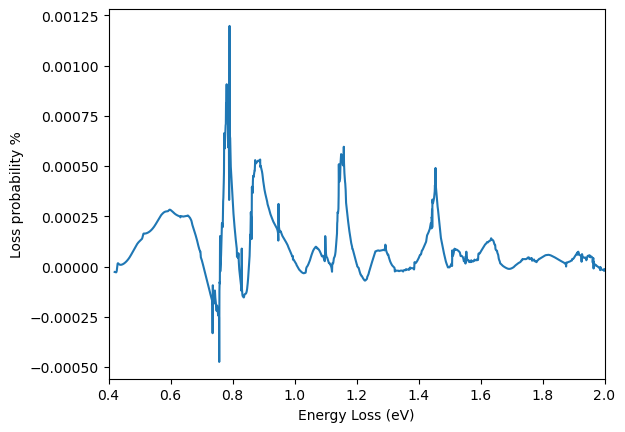

In [21]:
plt.figure()
# plt.plot(freqs[:int(N/2)+1]*h_bar/q_e, Gamma[:int(N/2)+1]*100)
plt.plot((freqs*h_bar/q_e)[int(0.2*M):], Gamma[int(0.2*M):])
# plt.plot((freqs*h_bar/q_e)[:], Gamma[:])
# plt.hlines(y=0,xmin=0,xmax=6, ls='--', lw=1, color='grey')
plt.xlabel('Energy Loss (eV)')
plt.ylabel('Loss probability %')
plt.xlim((0.4,2))

## Convolution with gaussian

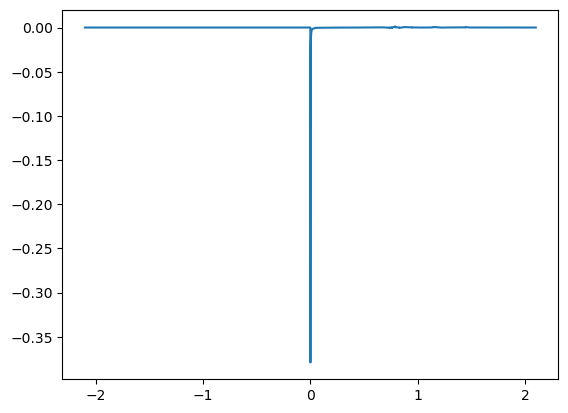

In [13]:
Gamma_ext = np.append(np.zeros(len(freqs)-1), Gamma)
freqs_ext = np.append((freqs[1:]*-1)[::-1],freqs)
plt.plot(freqs_ext*h_bar/q_e, Gamma_ext)

In [14]:
def gaussian(x, mu, sigma):
    return 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-(x-mu)**2/(2*sigma**2))

In [15]:
FWHM = 30e-3 # eV  # = 2*np.sqrt(2*np.log(2)) * sigma
sigma = FWHM/(2*np.sqrt(2*np.log(2)))

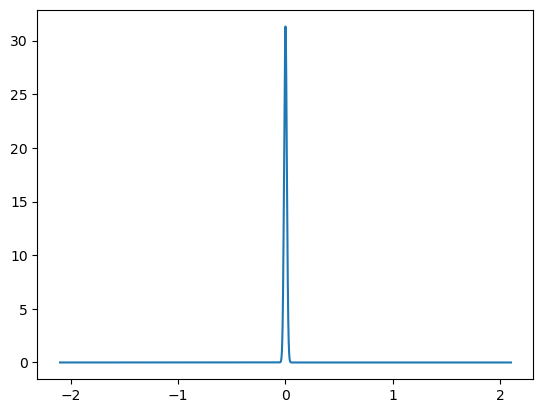

In [16]:
t = np.linspace(freqs[0],freqs[-1],len(freqs))
scale = t[-1]/(freqs[-1]*h_bar/q_e)
gauss = gaussian(freqs_ext*h_bar/q_e, 0, sigma)
plt.plot(freqs_ext*h_bar/q_e, gauss)

In [17]:
Gamma_c = np.convolve(Gamma_ext, gauss, mode='same')

(-0.25, 2.0)

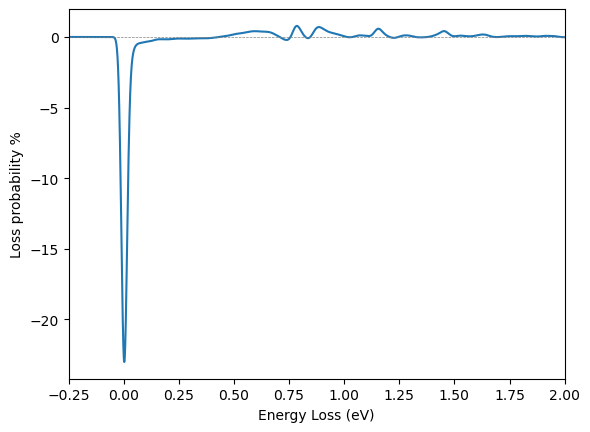

In [22]:
plt.figure()
plt.plot(freqs_ext*h_bar/q_e, Gamma_c)
plt.hlines(y=0,xmin=-0.25,xmax=2, ls='--', lw=0.5, color='grey')
plt.xlabel('Energy Loss (eV)')
plt.ylabel('Loss probability %')
plt.xlim((-0.25,2))
# plt.ylim(ymax=0.05)

(0.4, 1.05)

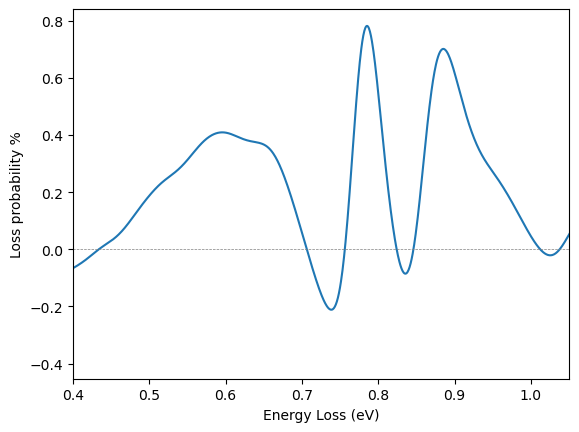

In [19]:
plt.figure()
plt.plot(freqs_ext[int(1.04*N):]*h_bar/q_e, Gamma_c[int(1.04*N):])
plt.hlines(y=0,xmin=0,xmax=2, ls='--', lw=0.5, color='grey')
plt.xlabel('Energy Loss (eV)')
plt.ylabel('Loss probability %')
plt.xlim((0.4,1.05))
# plt.ylim(ymin=-0.02,ymax=0.17)